In [1]:
import pandas as pd 
import numpy as np 

df = pd.read_csv("../data/raw/vehicle_sensor_data.csv")
df.head

c:\Users\busha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<bound method NDFrame.head of     vehicle_id            timestamp  engine_temperature  battery_voltage  \
0        VH002  2026-09-08 09:00:00              107.52            11.90   
1        VH003  2026-09-08 09:05:00              103.67            11.74   
2        VH005  2026-09-08 09:10:00              106.75            11.50   
3        VH001  2026-09-08 09:15:00               92.06            11.96   
4        VH002  2026-09-08 09:20:00               96.11            11.76   
..         ...                  ...                 ...              ...   
995      VH002  2026-09-11 19:55:00              101.84            11.61   
996      VH004  2026-09-11 20:00:00               93.96            11.78   
997      VH004  2026-09-11 20:05:00               86.37            12.50   
998      VH002  2026-09-11 20:10:00               96.67            12.42   
999      VH002  2026-09-11 20:15:00              103.66            12.92   

     vibration  brake_temperature  speed  mileage fault_c

In [2]:
df.shape

(1000, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   vehicle_id            1000 non-null   str    
 1   timestamp             1000 non-null   str    
 2   engine_temperature    1000 non-null   float64
 3   battery_voltage       1000 non-null   float64
 4   vibration             1000 non-null   float64
 5   brake_temperature     1000 non-null   float64
 6   speed                 1000 non-null   int64  
 7   mileage               1000 non-null   int64  
 8   fault_code            1000 non-null   str    
 9   maintenance_required  1000 non-null   str    
dtypes: float64(4), int64(2), str(4)
memory usage: 107.9 KB


In [4]:
df.describe()

,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,94.821000,12.262650,5.034930,90.342700,61.255000,55567.784000
std,8.636402,0.437194,2.283062,17.089164,23.180149,26074.643126
min,80.060000,11.500000,1.010000,60.110000,20.000000,10020.000000
25%,87.007500,11.880000,3.120000,75.905000,41.750000,33061.500000
50%,94.535000,12.260000,5.045000,90.095000,62.000000,56359.000000
75%,102.290000,12.642500,7.062500,104.837500,82.000000,78617.000000
max,109.970000,13.000000,8.990000,119.980000,100.000000,99976.000000


In [5]:
df.isnull().sum()

vehicle_id              0
timestamp               0
engine_temperature      0
battery_voltage         0
vibration               0
brake_temperature       0
speed                   0
mileage                 0
fault_code              0
maintenance_required    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

vehicle_id                  str
timestamp                   str
engine_temperature      float64
battery_voltage         float64
vibration               float64
brake_temperature       float64
speed                     int64
mileage                   int64
fault_code                  str
maintenance_required        str
dtype: object

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [9]:
df.dtypes

vehicle_id                         str
timestamp               datetime64[us]
engine_temperature             float64
battery_voltage                float64
vibration                      float64
brake_temperature              float64
speed                            int64
mileage                          int64
fault_code                         str
maintenance_required               str
dtype: object

In [10]:
df["maintenance_required"].value_counts()

maintenance_required
No     626
Yes    374
Name: count, dtype: int64

In [11]:
df["vehicle_id"].value_counts()

vehicle_id
VH002    212
VH004    207
VH003    205
VH001    203
VH005    173
Name: count, dtype: int64

In [12]:
df.groupby("vehicle_id")["engine_temperature"].mean()

vehicle_id
VH001    94.518719
VH002    94.958349
VH003    95.790829
VH004    94.204734
VH005    94.595549
Name: engine_temperature, dtype: float64

In [13]:
df[df["engine_temperature"] > 100]

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required
0,VH002,2026-09-08 09:00:00,107.52,11.90,3.01,87.31,50,33076,F000,Yes
1,VH003,2026-09-08 09:05:00,103.67,11.74,4.70,72.66,57,95784,F001,Yes
2,VH005,2026-09-08 09:10:00,106.75,11.50,4.05,91.00,99,31791,F001,Yes
5,VH005,2026-09-08 09:25:00,108.62,12.99,1.33,97.27,69,54895,F002,No
6,VH005,2026-09-08 09:30:00,104.97,12.62,1.61,109.94,82,81493,F001,Yes
...,...,...,...,...,...,...,...,...,...,...
986,VH004,2026-09-11 19:10:00,104.92,11.62,1.36,60.54,91,53507,F001,Yes
991,VH001,2026-09-11 19:35:00,101.77,12.84,1.99,69.12,49,67220,F000,No
994,VH003,2026-09-11 19:50:00,104.86,12.89,2.99,77.52,33,50471,F001,No
995,VH002,2026-09-11 19:55:00,101.84,11.61,7.02,64.44,82,55738,F000,Yes


In [14]:
df[df["vibration"]> 7]

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required
17,VH001,2026-09-08 10:25:00,84.43,12.45,7.58,94.78,33,91301,F002,No
23,VH001,2026-09-08 10:55:00,82.57,11.78,7.80,62.26,82,60786,F001,Yes
24,VH004,2026-09-08 11:00:00,103.78,12.28,8.64,66.86,87,91570,F002,Yes
28,VH005,2026-09-08 11:20:00,104.79,12.37,7.87,100.78,38,96397,F000,Yes
31,VH005,2026-09-08 11:35:00,89.37,11.96,8.16,91.84,61,22139,F001,Yes
...,...,...,...,...,...,...,...,...,...,...
983,VH005,2026-09-11 18:55:00,87.82,12.03,8.54,106.72,50,35616,F002,Yes
985,VH004,2026-09-11 19:05:00,100.86,12.02,7.80,86.22,70,67092,F000,Yes
995,VH002,2026-09-11 19:55:00,101.84,11.61,7.02,64.44,82,55738,F000,Yes
997,VH004,2026-09-11 20:05:00,86.37,12.50,7.60,60.17,40,50208,F002,No


In [15]:
df[df["battery_voltage"] < 12]

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required
0,VH002,2026-09-08 09:00:00,107.52,11.90,3.01,87.31,50,33076,F000,Yes
1,VH003,2026-09-08 09:05:00,103.67,11.74,4.70,72.66,57,95784,F001,Yes
2,VH005,2026-09-08 09:10:00,106.75,11.50,4.05,91.00,99,31791,F001,Yes
3,VH001,2026-09-08 09:15:00,92.06,11.96,6.02,67.53,98,23477,F001,No
4,VH002,2026-09-08 09:20:00,96.11,11.76,4.08,88.42,41,80012,F002,No
...,...,...,...,...,...,...,...,...,...,...
987,VH004,2026-09-11 19:15:00,98.86,11.55,4.83,103.89,50,54784,F001,Yes
990,VH003,2026-09-11 19:30:00,93.43,11.99,1.37,64.61,53,46852,F001,No
993,VH004,2026-09-11 19:45:00,80.46,11.63,5.27,82.51,23,62913,F000,No
995,VH002,2026-09-11 19:55:00,101.84,11.61,7.02,64.44,82,55738,F000,Yes


In [18]:
df.sort_values("engine_temperature",ascending=False)

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required
443,VH003,2026-09-09 21:55:00,109.97,11.97,7.22,76.70,32,13686,F000,Yes
52,VH002,2026-09-08 13:20:00,109.95,11.73,3.56,109.75,89,74588,F001,Yes
912,VH003,2026-09-11 13:00:00,109.85,11.91,6.43,84.10,85,46877,F001,Yes
179,VH003,2026-09-08 23:55:00,109.85,12.85,7.55,91.40,76,80221,F000,Yes
578,VH002,2026-09-10 09:10:00,109.81,11.88,1.87,70.97,86,45903,F000,Yes
...,...,...,...,...,...,...,...,...,...,...
962,VH004,2026-09-11 17:10:00,80.22,12.41,6.94,106.97,88,46488,F002,No
982,VH005,2026-09-11 18:50:00,80.13,12.94,1.21,94.54,91,54980,F002,No
178,VH003,2026-09-08 23:50:00,80.09,12.84,2.02,69.88,68,96628,F001,No
410,VH004,2026-09-09 19:10:00,80.08,12.57,4.48,69.70,38,19965,F002,No


In [19]:
df[df["battery_voltage"] < 12].sort_values("battery_voltage")

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required
116,VH005,2026-09-08 18:40:00,99.79,11.50,1.66,75.02,50,52107,F002,No
500,VH004,2026-09-10 02:40:00,80.65,11.50,5.52,90.60,65,15706,F000,No
2,VH005,2026-09-08 09:10:00,106.75,11.50,4.05,91.00,99,31791,F001,Yes
840,VH001,2026-09-11 07:00:00,93.67,11.51,6.06,119.50,61,84441,F002,Yes
391,VH004,2026-09-09 17:35:00,84.18,11.51,1.27,70.67,99,86709,F000,No
...,...,...,...,...,...,...,...,...,...,...
387,VH002,2026-09-09 17:15:00,96.48,11.98,4.61,83.59,65,50694,F001,No
976,VH005,2026-09-11 18:20:00,87.29,11.99,7.98,95.56,63,16120,F000,Yes
990,VH003,2026-09-11 19:30:00,93.43,11.99,1.37,64.61,53,46852,F001,No
689,VH005,2026-09-10 18:25:00,87.55,11.99,2.43,67.77,79,52568,F002,No


In [21]:
#checking for dublicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#find invalid engine_temperature
df[(df["engine_temperature"] < 0) | (df["engine_temperature"] > 150)]

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required


In [23]:
#find invalid battery_voltage
df[(df["battery_voltage"] < 10) | (df["battery_voltage"] > 15)]

,vehicle_id,timestamp,engine_temperature,battery_voltage,vibration,brake_temperature,speed,mileage,fault_code,maintenance_required


In [27]:
df["fault_code"].value_counts()

fault_code
F000    338
F002    335
F001    327
Name: count, dtype: int64

In [28]:
df["maintenance_required"].value_counts()

maintenance_required
No     626
Yes    374
Name: count, dtype: int64

In [29]:
np.mean(df["engine_temperature"])

np.float64(94.821)

In [30]:
np.max(df["vibration"])

8.99

In [31]:
np.min(df["battery_voltage"])

11.5

In [32]:
np.std(df["engine_temperature"])

8.632082691911615

In [33]:
df["maintenance_required"].value_counts()

maintenance_required
No     626
Yes    374
Name: count, dtype: int64

<Axes: xlabel='maintenance_required'>

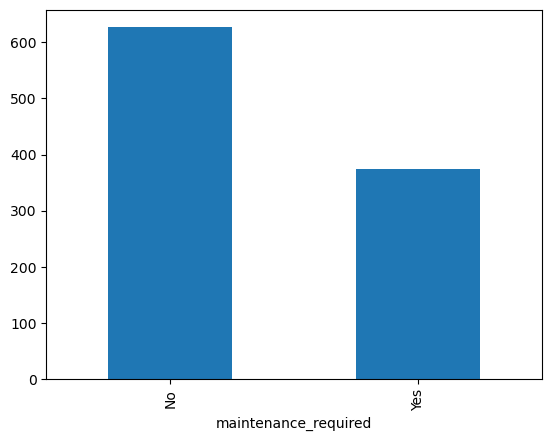

In [34]:
df["maintenance_required"].value_counts().plot(kind="bar")

<Axes: ylabel='Frequency'>

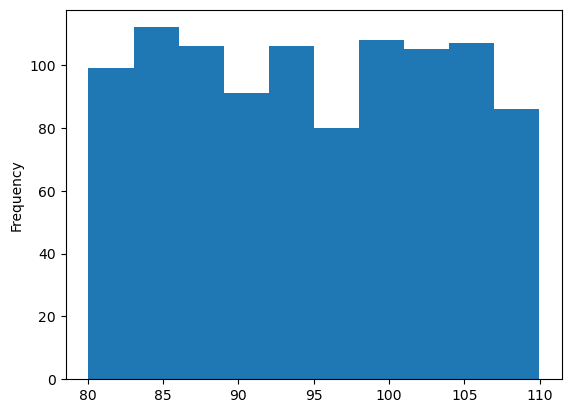

In [35]:
df["engine_temperature"].plot(kind="hist", bins=10)

In [36]:
df.groupby("maintenance_required")["engine_temperature"].mean()

maintenance_required
No     92.428722
Yes    98.825187
Name: engine_temperature, dtype: float64

In [37]:
df.groupby("maintenance_required")["vibration"].mean()

maintenance_required
No     4.496342
Yes    5.936417
Name: vibration, dtype: float64

<Axes: xlabel='engine_temperature', ylabel='vibration'>

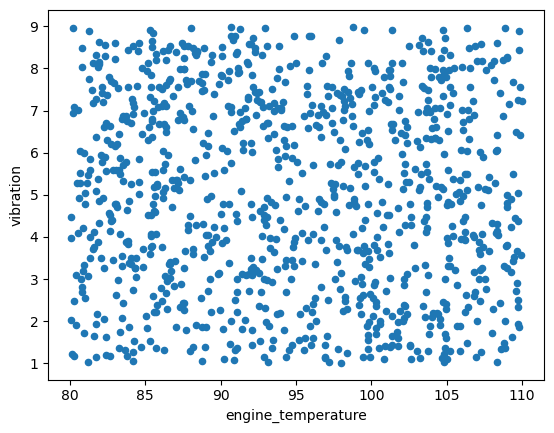

In [38]:
df.plot(
    x="engine_temperature",
    y="vibration",
    kind="scatter"
)

In [39]:
df.groupby("maintenance_required")["battery_voltage"].mean()

maintenance_required
No     12.367796
Yes    12.086658
Name: battery_voltage, dtype: float64

In [40]:
df.groupby("maintenance_required")["brake_temperature"].mean()

maintenance_required
No     85.750927
Yes    98.028396
Name: brake_temperature, dtype: float64

In [41]:
df.to_csv("../data/processed/vehicle_sensor_data_cleaned.csv", index=False)

In [42]:
import os

os.path.exists("../data/processed/vehicle_sensor_data_cleaned.csv")

True